# Unit 1 Assessment: Dataset 4 — Online Retail Transaction Analysis

## Part 1 — Evaluation, Cleaning and Standardisation

This is the first notebook in a two-part analysis of the supplied Online Retail transaction data. It establishes what arrived, investigates data-quality signals before making decisions, and builds a documented, reproducible cleaning process.

The purpose of this part is not to rush towards a chart.  I have split the notebook into two parts because I kept finding loose threads that needed to be pulled apart in the exploration, and the notebook as a single entity was becoming an epic saga in length.  So now I have two parts.  The first part deals with evaluation, exploration, understanding shape and nature, then once that is understood, moves onto cleaning and standardisation for analysis.  The second part is my visual analytical investigation of that prepared data.

I first evaluate the raw file and its provenance, then standardise fields, separate the primary paid-product analysis table from the excluded audit rows, and validate the result. The finished hand-off is saved for the second notebook, where the business questions and visual investigation continue.

## Objectives

- Load and inspect the supplied raw transaction data without changing it.
- Evaluate duplicates, cancellations, negative quantities, non-product lines, prices, descriptions, and identifier provenance before filtering.
- Record the reasoning behind each cleaning decision.
- Standardise the working fields and preserve an audit view of excluded rows.
- Create and validate a clean paid-product table with the measures needed for later analysis.
- Save a clear, reproducible hand-off for `02_investigate_visualise.ipynb`.

## Inputs and outputs

- Input: `../Data_Sets/Online_Retail.csv`
- Output: `../outputs/cleaned_online_retail.csv`
- ETL comparison visualisation: `../Images/Online_Retail_Analysis/`

This notebook runs top to bottom. Later cells depend on objects built earlier, so skipping around can break the evidence chain. The raw CSV remains untouched; all investigation and transformation happens on working copies. The findings remain descriptive: this part prepares trustworthy evidence, rather than claiming causes or profit that the data cannot show.

> Granular-refactor note: the cached outputs are retained from the previously executed notebook grouping. Run this notebook from the top to refresh each smaller cell in its new position.

# Phase 1 — setup and extraction

> Part 1 ends at the validated ETL hand-off. Product, market, and time investigation continue in Part 2.


### Business intent — growth and performance

This notebook opens with a story I believed at the time: somewhere in this dataset is one massive, mysterious customer — a whale — and I was going to be the one to find it. You'll see that hunt start in the early cells and then quietly die during the first proper look at the data. I've left that false start in place, because the exploration that killed it is exactly what taught me something true about the dataset. Once I realised my mistake, I had to pivot and build a hypothesis that didn't need a whale to survive.

So what follows is written for an imagined Commercial Director at an imagined UK-based online retailer. I want to understand their business: product performance, market value, activity over time, and where things might be underperforming. Busy and valuable turn out to be different things, so I compare transaction volume against revenue rather than assuming the busiest market is the best one.

Retail data like this earns its keep answering more than one question. The obvious ones are product performance — which lines earn their shelf space, and which only sell for one month a year — and market comparison, which is where "busy" and "valuable" split apart. Where the identifiers hold up, you can look at customer behaviour on top of that: repeat buyers, concentrated relationships, the one account quietly carrying an entire market. Time analysis feeds stock, staffing, and campaign planning, and underperformance analysis runs the same machinery in reverse, flagging the products, markets, or months worth a second look.

Further out still sit customer segmentation and demand forecasting, and I'm doing neither here. This stays descriptive. I'd rather report what the data shows than dress a description up as a prediction.

The immediate business challenge is straightforward to state and harder to solve: UK dominance, transaction noise, incomplete customer identity, and an unfinished final December all make it difficult to spot genuine international opportunity or plan for demand that's about to shift. This notebook exists to build measured evidence before recommending anything. An AI pipeline could help downstream of this — ranking markets, products and relationships by how much they merit a human look, forecasting demand once the time patterns can be trusted, flagging the unexpected. Building that sits well outside this notebook's scope. What I can usefully do here is work out which evidence a system like that would actually need feeding.

### Cell 1 — import the toolkit

In [1]:
# I load the libraries used for the analysis and give them familiar short names.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I use a readable default style for the later Seaborn charts.
sns.set_theme(style="whitegrid")

### Consequence — the analysis tools are ready

The notebook now has Pandas, NumPy, Matplotlib, and Seaborn available under their familiar short names. No data has been changed or analysed yet, so the next step is to load the supplied CSV into an untouched raw table.

### Cell 2 — load the raw file

In [2]:
# I load the supplied CSV into an untouched raw table so later transformations remain reversible.
df_raw = pd.read_csv("../Data_Sets/Online_Retail.csv")

### Consequence — the raw table is preserved

The supplied CSV is now in `df_raw`, kept separate from every later working copy. That gives me an honest starting point against which every cleaning decision can be checked. Next I preview the first rows.

### Cell 2A — preview the first rows

A small preview confirms that the file has loaded and gives me a first look at the row grain and field names.

In [3]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Consequence — the row grain is visible

The preview shows the transaction-line structure and the fields carried by each row. That first look is enough to move from “the file loaded” to measuring its size and column names.

### Cell 3 — establish the starting point

I record the starting shape and column names before asking any quality question.

In [4]:
# I establish the starting shape and fields before changing anything.
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Consequence — the starting shape is recorded

The raw table’s dimensions and column names are now recorded before any filtering. I know what arrived; next I check the types, missing-value reporting, and date coverage.

### Cell 3A — inspect types and date coverage

Now I check the data types, non-null counts, and observed date range.

In [5]:
df_raw.info()
print("InvoiceDate range:", pd.to_datetime(df_raw["InvoiceDate"]).min(),
      "to", pd.to_datetime(df_raw["InvoiceDate"]).max())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 69.3 MB
InvoiceDate range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


### Consequence — the raw structure and time window are known

The type report and converted date range show how the columns are stored and the period represented by the file. With that baseline fixed, I can begin quality investigation before deciding what to remove.

# Phase 2 — investigate data quality before deciding

The next cells inspect the raw signals in small steps. I show the rows or counts first, then record what those results mean.

### Cell 4A — inspect invoice-number prefixes

Which invoice prefixes are present, and how many rows sit behind each one?

In [6]:
# I treat invoice numbers as text so I can inspect their first-character prefixes.
invoice_text = df_raw["InvoiceNo"].astype("string")

invoice_prefix_counts = (
    invoice_text.str[0]
    .value_counts(dropna=False)
    .rename_axis("InvoiceNo prefix")
    .to_frame("Rows")
)
display(invoice_prefix_counts)

,Rows
InvoiceNo prefix,
5,532618
C,9288
A,3


### Consequence — invoice prefixes separate the next questions

The prefix counts distinguish ordinary invoice numbers from the `C` group and the small `A` group. The unusual `A` rows need direct inspection before I assign them a meaning, so that is the next step.

### Cell 4B — inspect the A-prefixed rows

I noticed the prefix inventory shows an unusual group, so I display its rows before deciding what it represents.

In [7]:
a_invoice_rows = df_raw.loc[
    invoice_text.str.startswith("A", na=False),
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"],
]
print("Rows with an A invoice prefix:")
display(a_invoice_rows)

Rows with an A invoice prefix:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
299982,A563185,B,Adjust bad debt,1,11062.06
299983,A563186,B,Adjust bad debt,1,-11062.06
299984,A563187,B,Adjust bad debt,1,-11062.06


### Consequence — the A-prefixed rows are exceptional adjustments

The displayed rows show the three `A`-prefixed records and their adjustment description. They are a small, identifiable exception rather than evidence that every non-numeric invoice prefix is a cancellation. Next I measure the wider quality signals.

### Cell 4C — inventory the main quality signals

How many missing values, exact duplicates, non-positive quantities, non-positive prices, and cancellation-style invoices are present?

In [8]:
# These counts describe quality signals; they do not decide the cleaning rules by themselves.
print("Missing values:")
display(df_raw.isna().sum())
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Quantity <= 0:", (df_raw["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df_raw["UnitPrice"] <= 0).sum())
print("Invoice numbers starting with C:",
      invoice_text.str.startswith("C", na=False).sum())

Missing values:


InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

Exact duplicate rows: 5268
Quantity <= 0: 10624
UnitPrice <= 0: 2517
Invoice numbers starting with C: 9288


### Consequence — several raw quality signals are present

Interesting. The inventory shows missing descriptions, exact duplicates, non-positive quantities, non-positive prices, and the surprising absence of null `CustomerID` values. These counts overlap and do not yet decide the cleaning rules, so the next question is why customer coverage looks so complete.

### Cell 4D — inspect CustomerID coverage

The missing-value count is surprising, so I check how many identifiers exist and how rows are distributed across them.

In [9]:
print("\nDistinct customer IDs:", df_raw["CustomerID"].nunique())
print("Rows per customer ID, five largest:")
display(df_raw["CustomerID"].value_counts().head(5))


Distinct customer IDs: 4372
Rows per customer ID, five largest:


CustomerID
15287    135101
17841      7983
14911      5903
14096      5128
12748      4642
Name: count, dtype: int64

### Consequence — the customer-ID anomaly is measurable

There are 4,372 distinct identifiers, no missing values in the raw column, and `15287` carries 135,101 rows while the next largest ID carries 7,983. That gap is too large to explain by ordinary customer variation alone, so I build the full ranked distribution next.

### Analysis — the customer ID anomaly

This is not what I expected at all. The historical reputation upon which I based my choice of project says roughly 135,000 rows should be missing a `CustomerID` — and this copy has none. Every row carries a number, stored as a whole integer, which is only possible if nothing's actually missing.

The distribution tells me what really happened:

- **Distinct customer IDs:** 4,372
- **Rows carrying `15287`:** 135,101
- **Rows carrying the next largest ID, `17841`:** 7,983

One identifier is holding roughly a quarter of the entire file and dwarfs the next-largest customer by a factor of seventeen. That number, 135,101, sits suspiciously close to the missing-value count the dataset is supposed to have. That's not a coincidence I'm willing to let go unchecked — so I plot it next rather than just squinting at a table.

### Cell 4E — prepare the customer-ID distribution

Five rows cannot show the shape of the full customer population, so I build a ranked table for the complete distribution.

In [10]:
# I count the rows carried by every customer ID, largest first.
customer_row_counts = df_raw["CustomerID"].value_counts()

# I build a small table so each customer's rank and row count can be inspected together.
customer_rank_table = pd.DataFrame({
    "Rank": range(1, len(customer_row_counts) + 1),
    "Rows": customer_row_counts.values,
    "CustomerID": customer_row_counts.index,
})

display(customer_rank_table.head())

,Rank,Rows,CustomerID
0,1,135101,15287
1,2,7983,17841
2,3,5903,14911
3,4,5128,14096
4,5,4642,12748


### Consequence — the full ranked table is ready to plot

The table makes the complete customer-ID distribution inspectable rather than relying on only five rows. The next step is to see whether the largest identifier sits on the same curve as the rest, or is an artefact outlier.

### Cell 4F — visualise the customer-ID distribution

The chart tests whether the largest identifier belongs to the same distribution as the other identifiers.

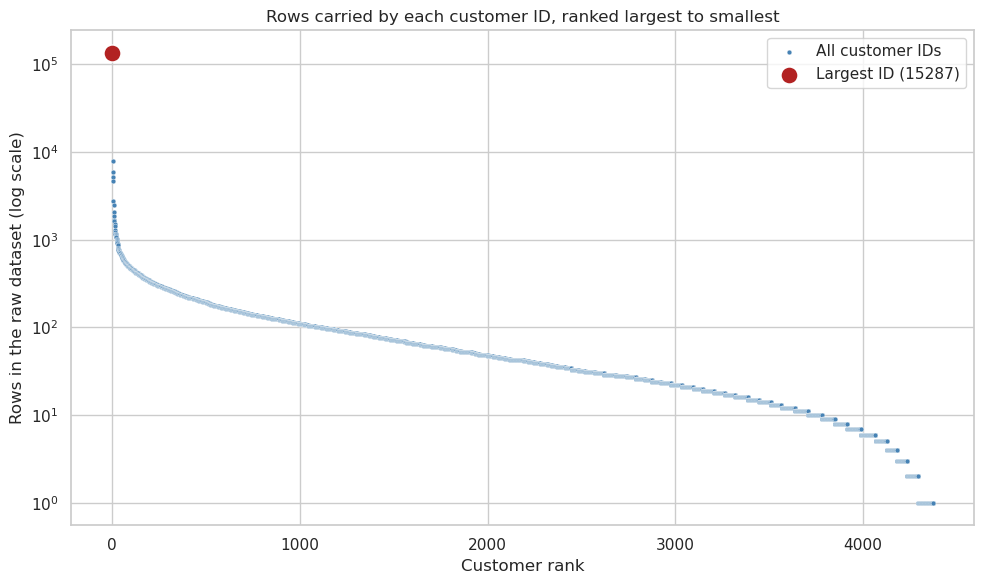

In [11]:
plt.figure(figsize=(10, 6))

# I plot every customer as a small point to show the shape of the distribution.
sns.scatterplot(
    data=customer_rank_table,
    x="Rank",
    y="Rows",
    s=12,
    color="steelblue",
    label="All customer IDs",
)

# I mark the top-ranked identifier so its distance from the rest is obvious.
sns.scatterplot(
    data=customer_rank_table.head(1),
    x="Rank",
    y="Rows",
    s=150,
    color="firebrick",
    label="Largest ID (15287)",
)

# I use a logarithmic scale so the full distribution remains visible while the outlier stays clear.
plt.yscale("log")
plt.title("Rows carried by each customer ID, ranked largest to smallest")
plt.xlabel("Customer rank")
plt.ylabel("Rows in the raw dataset (log scale)")
plt.legend()
plt.tight_layout()

# I save the completed figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_customer_id_ghost.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the outlier is separated from the distribution

The completed log-scale scatter shows `15287` detached above the steadily declining pattern of the other identifiers. That is evidence for a placeholder bucket rather than an unusually large customer, so the next Markdown cell records what this changes for the analysis.

### Analysis — the ghost whale

Well, there it is.

Every real customer sits on a smooth curve that decays steadily from a few thousand rows down to a handful. That's what a customer base looks like. The top-ranked identifier isn't at the top of that curve — it's detached from it, sitting well clear of the customer ranked below it.

A point that doesn't belong to the distribution it's plotted in isn't an unusually good customer. It's a container. A placeholder for something else.

I spent a considerable stretch early on in this project hunting that point as though it were a real buyer — an enormous account worth understanding, worth chasing. This chart is where the whale turned out to be a ghost. `15287` isn't a customer at all. It's every transaction whose customer was never recorded, swept together under one invented number by whoever prepared this copy of the data, long before it reached me.

**What this changes, and what it doesn't.** Revenue, product, country, and time analysis are unaffected — those transactions are real sales, with real dates, real prices, and real destinations. It's only the identity of the buyer that was never captured. Anything counted *per customer* is affected, so from here on I count identified customers and say so, rather than pretending the total is complete.

This notebook carries on now as if nothing happened, but something did. I've just spent half a day rethinking what's actually worth understanding here, and how that could matter to someone who isn't a bootcamp student learning to wrangle data. What I've taken from it is this: understanding what you're investigating is just as important as the investigation you planned.

The same inventory also shows 9,288 invoice numbers beginning with `C`. I investigate that prefix next by comparing it with the negative-quantity rows.

### Cell 5 — inspect cancellations and negative quantities

The prefix inventory shows three groups: ordinary numeric invoice numbers, a distinct C group containing 9,288 rows, and three rows starting with A. The A rows are few enough to check directly — all three carry the description B / Adjust bad debt — so I set them aside here and pick them up again when I look at non-numeric stock codes. The C group is the one worth investigating now: I compare those rows with the negative-quantity records to test whether the prefix identifies cancellations or returns, while leaving the non-C group open until the rows and descriptions earn me an answer.

### Cell 5A — count cancellation-style and other negative quantities

I create the masks and print the two counts separately before inspecting the exception rows.

In [12]:
# I identify cancellation-style invoices and negative quantities separately.
cancellation_mask = invoice_text.str.startswith("C", na=False)
negative_quantity_mask = df_raw["Quantity"] < 0
other_negative_mask = negative_quantity_mask & ~cancellation_mask

print("Negative quantities with a C invoice:",
      (negative_quantity_mask & cancellation_mask).sum())
print("Negative quantities without a C invoice:",
      other_negative_mask.sum())

Negative quantities with a C invoice: 9288
Negative quantities without a C invoice: 1336


### Consequence — cancellations and other negative quantities are different groups

The counts show 9,288 negative rows with a `C` prefix and 1,336 negative rows without one. The non-`C` group needs direct inspection before it can be classified, so I display sample rows next.

### Cell 5B — inspect non-C negative-quantity rows

The non-C group needs its own evidence because its business meaning is not established by the prefix alone.

In [13]:
# I display sample exception rows so I can investigate their meaning before cleaning.
display(df_raw.loc[
    other_negative_mask,
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20))

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
2406,536589,21777,NaN,-10,0.0,United Kingdom
4347,536764,84952C,NaN,-38,0.0,United Kingdom
7188,536996,22712,NaN,-20,0.0,United Kingdom
7189,536997,22028,NaN,-20,0.0,United Kingdom
7190,536998,85067,NaN,-6,0.0,United Kingdom
7192,537000,21414,NaN,-22,0.0,United Kingdom
7193,537001,21653,NaN,-6,0.0,United Kingdom
7195,537003,85126,NaN,-2,0.0,United Kingdom
7196,537004,21814,NaN,-30,0.0,United Kingdom
7197,537005,21692,NaN,-70,0.0,United Kingdom


### Consequence — the non-C exceptions remain unresolved

The sample is dominated by missing descriptions and zero prices, so these rows do not yet identify a single business meaning. I keep them as a separate quality group and next investigate the mixed non-numeric stock-code population.

### Analysis — what the negative-quantity output tells me

Every `C` invoice row also carries a negative quantity, so in this dataset the `C` prefix is a reliable flag for cancellation-style records. But one thing doesn't fit:

- **Total negative-quantity rows:** 10,624
- **Negative-quantity rows with no `C` prefix:** 1,336

Those 1,336 rows don't follow the obvious pattern. The displayed sample has missing descriptions and zero prices, so it does not identify their exact business meaning. I keep them outside ordinary paid-sales analysis and leave their meaning open.

### Cell 6 — inspect non-product stock codes

Some stock codes don't start with a digit, and that group is a mixed bag — postage, fees, adjustments, vouchers, and, buried in there, genuine product rows. This cell just marks the group out as worth a closer look. Whether any of it actually gets removed is a separate question, and I answer it later, once I've got the evidence to back it up.

### Cell 6A — identify non-numeric-leading stock codes

I standardise the stock-code text and create the mask used for the focused investigation.

In [14]:
# I standardise stock codes as trimmed text before testing their first character.
stock_text = df_raw["StockCode"].astype("string").str.strip()
non_numeric_mask = ~stock_text.str.match(r"^\d", na=False)
print("Rows with non-numeric-leading stock codes:", non_numeric_mask.sum())

Rows with non-numeric-leading stock codes: 2995


### Consequence — the non-numeric group is small but mixed

The mask identifies 2,995 rows whose stock codes do not begin with a digit. That is a group to describe, not a reason to delete everything in it, so I next count the codes and descriptions.

### Cell 6B — describe the non-numeric code population

The same mask contains several kinds of line, so I inspect code frequencies and descriptions before filtering anything.

In [15]:
non_product_rows = df_raw.loc[non_numeric_mask]
display(non_product_rows["StockCode"].value_counts().head(20))
non_numeric_description_counts = (
    non_product_rows.groupby(["StockCode", "Description"]).size()
    .reset_index(name="Rows")
    .sort_values(["StockCode", "Description"])
)
display(non_numeric_description_counts)

StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
gift_0001_50       4
PADS               4
gift_0001_40       3
B                  3
DCGS0076           2
Name: count, dtype: int64

,StockCode,Description,Rows
0,AMAZONFEE,AMAZON FEE,34
1,B,Adjust bad debt,3
2,BANK CHARGES,Bank Charges,37
3,C2,CARRIAGE,143
4,CRUK,CRUK Commission,16
5,D,Discount,77
6,DCGS0003,BOXED GLASS ASHTRAY,4
7,DCGS0003,ebay,1
8,DCGS0004,HAYNES CAMPER SHOULDER BAG,1
9,DCGS0067,ebay,1


### Consequence — code frequencies show heterogeneous line types

The non-numeric group contains postage, fees, adjustments, vouchers, and other labels. A blanket non-numeric filter would mix operational rows with possible product rows, so the next step inspects actual examples.

### Cell 6C — inspect a sample of non-numeric-leading rows

In [16]:
display(non_product_rows[[
    "StockCode", "Description", "Quantity", "UnitPrice"
]].head(20))

,StockCode,Description,Quantity,UnitPrice
45,POST,POSTAGE,3,18.00
141,D,Discount,-1,27.50
386,POST,POSTAGE,1,15.00
1123,POST,POSTAGE,1,18.00
1423,C2,CARRIAGE,1,50.00
1814,DOT,DOTCOM POSTAGE,1,569.77
2239,M,Manual,1,1.25
2250,M,Manual,1,18.95
3041,DOT,DOTCOM POSTAGE,1,607.49
4406,BANK CHARGES,Bank Charges,1,15.00


### Consequence — the non-numeric sample confirms the mixed population

The sample contains both operational-looking lines and product-like rows. I therefore need a narrower, evidence-based exclusion rule and next compare the price, description, and duplicate conditions separately.

### Analysis — the mixed non-numeric population

Mmm. Non-numeric stock codes are a small slice of the dataset by row count, but their effect on revenue isn't uniform at all. Postage, carriage, fees, discounts, samples, vouchers — and, mixed in among them, descriptions that read as genuinely product-related. That mix rules out treating the whole group as one blanket category. I want the remaining price and description evidence in front of me before I write down the final ETL rules.

### Cell 7 — inspect prices, descriptions, and duplicates

I split out zero prices, negative prices, missing descriptions, and duplicates one at a time. Keeping each condition visible on its own means I can actually explain the cleaning rules afterwards, rather than burying them inside one large, unexplained mask.

### Cell 7A — count price, description, and duplicate conditions

I keep each condition named so the counts can be compared without collapsing different reasons together.

In [17]:
# I keep each condition as a named mask so I can count and inspect it separately.
zero_price_mask = df_raw["UnitPrice"] == 0
negative_price_mask = df_raw["UnitPrice"] < 0
missing_description_mask = df_raw["Description"].isna()

print("UnitPrice == 0:", zero_price_mask.sum())
print("UnitPrice < 0:", negative_price_mask.sum())
print("Missing Description:", missing_description_mask.sum())
print("Missing descriptions with positive prices:",
      (missing_description_mask & (df_raw["UnitPrice"] > 0)).sum())
print("Exact duplicate rows:", df_raw.duplicated().sum())

UnitPrice == 0: 2515
UnitPrice < 0: 2
Missing Description: 1454
Missing descriptions with positive prices: 0


Exact duplicate rows: 5268


### Consequence — price, description, and duplicate conditions are isolated

The named masks let me count and inspect each condition without collapsing different problems into one rule. The next output shows which rows are affected before I write the cleaning decisions.

### Cell 7B — inspect rows affected by those conditions

In [18]:
# I combine the visible conditions only for a focused inspection table.
display(df_raw.loc[
    zero_price_mask | negative_price_mask | missing_description_mask,
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(30))

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


### Consequence — the affected rows do not all mean the same thing

The displayed rows show zero-price records, negative-price records, and missing descriptions in the raw file. Their overlap matters, so I can now create a working copy and translate only the supported decisions into named masks.

### Analysis — the price and description evidence

I'm happier now. The zero-price rows, the two negative-price rows, and the missing descriptions all sit inside the same non-positive-price population — none of them spill over into a separate positive-price group I'd need to worry about. So for the primary paid-sales analysis, non-positive-price rows are out, and I won't be inventing missing descriptions to paper over the gap. They all stay in the raw dataset, available for audit whenever someone wants to look.

### Decision checkpoint — investigation and decisions

The raw dataset stays exactly as it arrived, kept as the permanent audit source. The working analysis table, by contrast, is built to represent paid product sales — not every transaction-like row that happens to sit in the file.

Exact duplicate rows come out of the working table, so identical records don't get double-counted. `C`-invoice rows and the 1,336 negative-quantity rows without a `C` prefix are held apart from gross product sales too. The non-`C` sample does not establish their exact business meaning, so I leave that question open rather than labelling them more specifically.

For the `C`-invoice rows specifically, I go a step further and look for the positive line each one may be reversing, before any cleaning happens. The match runs on identical `CustomerID`, `StockCode`, `UnitPrice`, and absolute `Quantity`; the positive line has to be strictly earlier, within 24 hours of the cancellation; and where more than one candidate exists, I resolve it one-to-one by picking the nearest preceding unused line. `CustomerID` 15287 is excluded from this matching altogether, because it's a placeholder rather than a reliable identity — matching on it would risk cancelling one anonymous buyer's order against a completely different anonymous buyer's purchase.

A matched positive line comes out of the paid-sales table and gets kept, alongside its cancellation, in the excluded audit view. Where the matched raw line turns out to be an exact duplicate already caught by deduplication, I link it back to the retained copy rather than counting it twice — which is why the audit can show 637 resolved line links while the saved clean table only physically removes 627 unique rows. Later matches, partial-quantity matches, and anything involving the placeholder ID stay unresolved on purpose, because they might just as easily be returns or unrelated anonymous activity, and I'd rather leave a genuine sale in than delete one on a guess.

Zero-price rows and the two negative-price rows are excluded from paid-sales metrics too, since neither can represent ordinary paid revenue, and missing descriptions aren't imputed for the core sales analysis — both stay available through the audit source if anyone wants to dig further ... (Don't).

Operational and financial non-numeric stock codes — postage, carriage, discounts, samples, bank charges, fees, commissions, bad debt, manual adjustments — are excluded from product-level analysis, while product-like non-numeric codes are kept wherever they represent genuine positive-price product lines.

None of this says the excluded rows are worthless. Cancellations, returns, and adjustments are real business events — they just don't belong in the primary sales table, where they'd otherwise get counted as ordinary sales and quietly inflate the numbers.

# Phase 3 — clean, transform, and validate

### Cell 8 — create a working copy and standardise fields

Finally! Time to actually build something. I create a working copy and standardise the text and date fields on it. Nothing gets removed here and none of the decisions above get overwritten — this step is purely reversible, a tidy-up before the real cleaning starts.

### Cell 8 — create a working copy and standardise fields

In [19]:
# I copy the raw table so standardisation does not alter my audit source.
df = df_raw.copy()

# I convert dates and trim text fields for reliable later comparisons.
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype("string").str.strip()
df["StockCode"] = df["StockCode"].astype("string").str.strip()
df["Description"] = df["Description"].astype("string").str.strip()

### Consequence — the raw audit source remains untouched

The working copy is now standardised for reliable comparisons while `df_raw` remains available as the audit source. The next step turns the confirmed decisions into visible exclusion masks.

### Cell 9A.1 — create the confirmed exclusion masks

I translate the decisions above into named masks, keeping the rules visible before building the clean table.

In [20]:
# I name each confirmed condition so I can inspect it before building the clean table.
duplicate_mask = df.duplicated()
cancellation_mask = df["InvoiceNo"].str.startswith("C", na=False)
negative_quantity_mask = df["Quantity"] < 0
non_c_negative_mask = negative_quantity_mask & ~cancellation_mask
non_positive_price_mask = df["UnitPrice"] <= 0
non_numeric_mask = ~df["StockCode"].str.match(r"^\d", na=False)

### Consequence — the core exclusion conditions are named

The duplicate, cancellation, non-`C` negative, and non-positive-price conditions now exist as separate masks. I next identify the operational and financial code categories rather than treating every non-numeric code as a removal.

### Cell 9A.2 — identify operational and financial non-product lines

These codes are excluded from the paid-product scope, while product-like positive-price rows remain eligible.

In [21]:
operational_codes = {
    "POST", "DOT", "M", "m", "C2", "D", "S",
    "BANK CHARGES", "AMAZONFEE", "CRUK", "B"
}
operational_mask = non_numeric_mask & (
    df["StockCode"].isin(operational_codes)
    | df["StockCode"].str.startswith("gift_", na=False)
)

### Consequence — operational codes are explicit rather than blanket-filtered

The exclusion list records the particular operational, financial, adjustment, and voucher codes supported by the earlier evidence. The next output checks which positive-price non-numeric rows should remain as product-like lines.

### Cell 9A.3 — confirm retained product-like non-numeric rows

I display the positive-price product-like exceptions so the rule does not silently become a blanket non-numeric filter.

In [22]:
retained_product_like_mask = (
    non_numeric_mask
    & ~operational_mask
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
)
print("Retained positive-price product-like non-numeric rows:", retained_product_like_mask.sum())
display(df.loc[retained_product_like_mask,
               ["StockCode", "Description", "Quantity", "UnitPrice"]].head(10))

Retained positive-price product-like non-numeric rows: 36


,StockCode,Description,Quantity,UnitPrice
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,16.13
24906,DCGS0003,BOXED GLASS ASHTRAY,1,2.51
36460,DCGS0003,BOXED GLASS ASHTRAY,1,2.51
39313,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,2,16.13
40052,DCGS0070,CAMOUFLAGE DOG COLLAR,1,12.72
75053,DCGS0069,OOH LA LA DOGS COLLAR,1,15.79
76251,DCGS0003,BOXED GLASS ASHTRAY,1,2.46
84016,DCGSSBOY,BOYS PARTY BAG,1,3.29
84017,DCGSSGIRL,GIRLS PARTY BAG,3,3.29
97246,DCGSSBOY,BOYS PARTY BAG,1,3.29


### Consequence — product-like exceptions are retained deliberately

The output shows the small set of positive-price, product-like non-numeric rows that remain eligible. With that boundary fixed, I can build the cancellation candidates without losing legitimate product lines.

### Cell 9B — match cancellation lines

Then, (after much consultation and planning with CODEX) I match a positive line to a later cancellation only when customer, stock code, price, quantity, and the 24-hour window all agree. The counts below show candidate links and the one-to-one matches retained.

### Cell 9B.1 — build positive-line candidates

Only positive, non-cancellation lines with a reliable customer identifier can be candidates for a cancellation match.

In [23]:
positive_candidates = df.loc[
    (df["Quantity"] > 0)
    & ~cancellation_mask
    & (df["CustomerID"] != 15287),
    ["CustomerID", "StockCode", "UnitPrice", "Quantity", "InvoiceDate", "InvoiceNo"],
].copy()
positive_candidates["OriginalRowID"] = positive_candidates.index
positive_candidates["AbsoluteQuantity"] = positive_candidates["Quantity"]
positive_candidates = positive_candidates.rename(columns={
    "Quantity": "OriginalQuantity",
    "InvoiceDate": "OriginalDate",
    "InvoiceNo": "OriginalInvoiceNo",
})

### Consequence — eligible positive originals are defined

The candidate table limits cancellation matching to positive, non-cancellation lines with reliable customer identifiers and the required fields. Next I define the cancellation-side candidates using the same matching vocabulary.

### Cell 9B.2 — build cancellation candidates

In [24]:
cancellation_candidates = df.loc[
    cancellation_mask
    & (df["Quantity"] < 0)
    & (df["CustomerID"] != 15287),
    ["CustomerID", "StockCode", "UnitPrice", "Quantity", "InvoiceDate", "InvoiceNo"],
].copy()
cancellation_candidates["CancellationRowID"] = cancellation_candidates.index
cancellation_candidates["AbsoluteQuantity"] = cancellation_candidates["Quantity"].abs()
cancellation_candidates = cancellation_candidates.rename(columns={
    "Quantity": "CancellationQuantity",
    "InvoiceDate": "CancellationDate",
    "InvoiceNo": "CancellationInvoiceNo",
})

### Consequence — cancellation candidates are constrained

The cancellation-side table contains negative `C` rows with the placeholder ID excluded from matching. The next step pairs both sides on customer, product, price, and absolute quantity before applying the time rule.

### Cell 9B.3 — create and time-filter candidate pairs

A candidate must match customer, stock code, price, and absolute quantity, with the positive line strictly earlier and no more than 24 hours before the cancellation.

In [25]:
cancel_match_candidates = cancellation_candidates.merge(
    positive_candidates,
    on=["CustomerID", "StockCode", "UnitPrice", "AbsoluteQuantity"],
    how="inner",
)
cancel_match_candidates = cancel_match_candidates[
    cancel_match_candidates["OriginalDate"] < cancel_match_candidates["CancellationDate"]
].copy()
cancel_match_candidates["GapHours"] = (
    cancel_match_candidates["CancellationDate"]
    - cancel_match_candidates["OriginalDate"]
).dt.total_seconds() / 3600
cancel_match_candidates = cancel_match_candidates[
    cancel_match_candidates["GapHours"] <= 24
].copy()
cancel_match_candidates["OriginalRevenue"] = (
    cancel_match_candidates["OriginalQuantity"]
    * cancel_match_candidates["UnitPrice"]
)

### Consequence — possible links are now testable

The merged candidates contain rows that match on the business keys and fall within the permitted time window. I next resolve competing candidates one-to-one so one original line cannot be used twice.

### Cell 9B.4 — resolve candidate pairs one-to-one

When several candidates remain, I choose the nearest preceding unused original for each cancellation.

In [26]:
used_original_rows = set()
resolved_match_rows = []
for cancellation_row_id, candidate_group in (
    cancel_match_candidates
    .sort_values(["CancellationRowID", "GapHours", "OriginalRowID"])
    .groupby("CancellationRowID", sort=False)
):
    available_candidates = candidate_group[
        ~candidate_group["OriginalRowID"].isin(used_original_rows)
    ]
    if not available_candidates.empty:
        chosen_match = available_candidates.iloc[0]
        resolved_match_rows.append(chosen_match)
        used_original_rows.add(chosen_match["OriginalRowID"])

resolved_matches = pd.DataFrame(resolved_match_rows)

### Consequence — each cancellation gets at most one original

The matching loop chooses the nearest preceding unused positive line for each cancellation. The next output reports the candidate and resolved counts and shows sample links for inspection.

### Cell 9B.5 — inspect the cancellation-match evidence

In [27]:
print("Candidate pairs within 24 hours:", len(cancel_match_candidates))
print("Resolved one-to-one pairs:", len(resolved_matches))
display(resolved_matches[[
    "CancellationInvoiceNo", "OriginalInvoiceNo", "StockCode",
    "OriginalQuantity", "UnitPrice", "GapHours"
]].head(10))

Candidate pairs within 24 hours: 759
Resolved one-to-one pairs: 669


,CancellationInvoiceNo,OriginalInvoiceNo,StockCode,OriginalQuantity,UnitPrice,GapHours
22,C537143,537140,20685,1,7.95,0.083333
24,C537157,537144,35953,24,1.25,0.150000
28,C537314,537298,21349,4,6.75,0.083333
32,C537379,537377,22865,10,2.10,0.183333
36,C537402,537217,22926,4,5.95,23.050000
38,C537402,537217,22927,4,5.95,23.050000
40,C537402,537217,22849,4,14.95,23.050000
42,C537402,537217,22847,4,14.95,23.050000
44,C537402,537216,47580,6,2.55,23.050000
46,C537402,537216,22196,12,0.85,23.050000


### Consequence — the cancellation links are auditable

The counts and sample links show how many candidate pairs were found and how many were resolved under the one-to-one rule. I can now map matched originals through deduplication and build the clean and excluded tables.

### Cell 9C — build clean and audit tables

Finally, I now map duplicate matches to their retained representatives, keep every excluded row in an audit table, and build the clean table used later. The final counts show exactly what was removed and why.

### Cell 9C.1 — map duplicate matched lines to retained representatives

A matched positive line may itself be an exact duplicate, so I map it to the representative that survives ordinary deduplication.

In [28]:
resolved_matches["CleanOriginalRowID"] = resolved_matches["OriginalRowID"]
duplicate_original_ids = resolved_matches.loc[
    resolved_matches["OriginalRowID"].isin(df.index[duplicate_mask]),
    "OriginalRowID",
]


### Consequence — matched duplicates have retained representatives

The matched positive rows are mapped to the representative rows that survive deduplication. I next create the deduplicated working table so the physical removals can be reconciled clearly.

### Next step — create the deduplicated working table

The previous mapping shows which matched rows are duplicates. I now remove only the exact duplicate rows from the working copy while preserving the original row IDs needed for the audit.

In [29]:
duplicate_originals = df.loc[
    df.index.isin(duplicate_original_ids)
].reset_index(names="OriginalRowID")
deduplicated_rows = df.loc[~duplicate_mask].reset_index(names="RepresentativeRowID")
duplicate_representatives = duplicate_originals.merge(
    deduplicated_rows,
    on=list(df.columns),
    how="left",
)[["OriginalRowID", "RepresentativeRowID"]]
duplicate_representative_map = duplicate_representatives.set_index(
    "OriginalRowID"
)["RepresentativeRowID"]
duplicate_match_mask = resolved_matches["OriginalRowID"].isin(
    duplicate_representative_map.index
)
resolved_matches.loc[duplicate_match_mask, "CleanOriginalRowID"] = (
    resolved_matches.loc[duplicate_match_mask, "OriginalRowID"]
    .map(duplicate_representative_map)
)

### Consequence — deduplication is ready for audit construction

The deduplicated rows and retained identifiers are now prepared for the exclusion log. The next step records every excluded row, including cancellation lines and matched originals, with a reason.

### Cell 9C.2 — build the excluded audit table

Every excluded row remains available for audit, including cancellation rows and matched positive originals.

In [30]:
matched_link_original_mask = df.index.isin(resolved_matches["OriginalRowID"])
matched_original_mask = df.index.isin(resolved_matches["CleanOriginalRowID"])

df_excluded = df.loc[
    duplicate_mask
    | cancellation_mask
    | non_c_negative_mask
    | operational_mask
    | non_positive_price_mask
    | matched_original_mask
].copy()
df_excluded["MatchedCancellationOriginal"] = (
    matched_link_original_mask | matched_original_mask
)[df_excluded.index]

print("Excluded rows retained for audit:", df_excluded.shape[0])

Excluded rows retained for audit: 19996


### Consequence — the exclusion audit is preserved

The audit table now holds the rows removed from the primary analysis together with the reasons for exclusion. That lets me build the paid-product table without losing the ability to explain what was removed.

### Cell 9C.3 — build the clean paid-product table

In [31]:
df_clean = df.loc[
    ~duplicate_mask
    & ~cancellation_mask
    & ~non_c_negative_mask
    & ~operational_mask
    & ~non_positive_price_mask
    & ~matched_original_mask
].copy()
print("Clean shape:", df_clean.shape)

Clean shape: (521913, 8)


### Consequence — the paid-product scope is explicit

The clean table now applies the documented duplicate, cancellation, operational, and price rules. The next step reconciles matched links with physical removals so the two totals are not confused.

### Cell 9C.4 — reconcile resolved links and physical removals

These measures explain why linked cancellation pairs and physically removed rows are not identical counts.

In [32]:
clean_scope_match_mask = resolved_matches["CleanOriginalRowID"].isin(df.index[
    ~duplicate_mask
    & ~cancellation_mask
    & ~non_c_negative_mask
    & ~operational_mask
    & ~non_positive_price_mask
])
resolved_clean_matches = resolved_matches.loc[clean_scope_match_mask].copy()
physical_clean_match_mask = matched_original_mask & (
    ~duplicate_mask
    & ~cancellation_mask
    & ~non_c_negative_mask
    & ~operational_mask
    & ~non_positive_price_mask
)
physical_clean_revenue = (
    df.loc[physical_clean_match_mask, "Quantity"]
    * df.loc[physical_clean_match_mask, "UnitPrice"]
).sum()


### Consequence — reconciliation flags are prepared

The matching results have been compared with the rows eligible to remain in the clean scope. I now print the reconciliation totals and values so the physical removal count can be checked.

### Next step — print the reconciliation totals

The previous cell prepared the flags that distinguish linked cancellation originals from unique physical rows. I now display those totals before adding any business measures.

In [33]:
print("Resolved originals still in the clean scope:", len(resolved_clean_matches))
print("Unique clean rows physically removed:", physical_clean_match_mask.sum())
print("Candidate pair rows not selected:", len(cancel_match_candidates) - len(resolved_matches))
print("Revenue removed from the clean scope:", round(resolved_clean_matches["OriginalRevenue"].sum(), 2))
print("Revenue removed from the saved clean table:", round(physical_clean_revenue, 2))
display(resolved_clean_matches[[
    "CancellationInvoiceNo", "OriginalInvoiceNo", "StockCode",
    "OriginalQuantity", "UnitPrice", "GapHours", "OriginalRevenue"
]].head(10))

Resolved originals still in the clean scope: 637
Unique clean rows physically removed: 627
Candidate pair rows not selected: 90
Revenue removed from the clean scope: 291902.64
Revenue removed from the saved clean table: 291829.44


,CancellationInvoiceNo,OriginalInvoiceNo,StockCode,OriginalQuantity,UnitPrice,GapHours,OriginalRevenue
22,C537143,537140,20685,1,7.95,0.083333,7.95
24,C537157,537144,35953,24,1.25,0.150000,30.00
28,C537314,537298,21349,4,6.75,0.083333,27.00
32,C537379,537377,22865,10,2.10,0.183333,21.00
36,C537402,537217,22926,4,5.95,23.050000,23.80
38,C537402,537217,22927,4,5.95,23.050000,23.80
40,C537402,537217,22849,4,14.95,23.050000,59.80
42,C537402,537217,22847,4,14.95,23.050000,59.80
44,C537402,537216,47580,6,2.55,23.050000,15.30
46,C537402,537216,22196,12,0.85,23.050000,10.20


### Consequence — linked cancellations and physical removals reconcile

The printed totals distinguish resolved links from unique clean rows removed, including the duplicate-link case. With that audit check complete, I can calculate the measures needed for Part 2.

### Cell 10 — create the business measures

Now, with the table finally clean, I can add the fields the three business questions actually need. `Revenue` is simple line revenue — quantity times unit price, nothing fancier. `Month` feeds the time question, and I leave `DayOfWeek` sitting there ready, in case a later avenue of investigation wants it.

### Cell 10A — calculate line revenue

In [34]:
# I calculate line revenue without changing the raw table.
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

### Consequence — line revenue is defined

Each retained row now has `Revenue = Quantity × UnitPrice`, which is recorded line revenue rather than profit or margin. The next step adds the simple time fields needed for the later monthly and weekly questions.

### Cell 10B — add the time fields used by Part 2

In [35]:
# I create simple time fields for the monthly question and a possible weekday extension.
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype("string")
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

display(df_clean[["Quantity", "UnitPrice", "Revenue", "Month"]].head())

,Quantity,UnitPrice,Revenue,Month
0,6,2.55,15.30,2010-12
1,6,3.39,20.34,2010-12
2,8,2.75,22.00,2010-12
3,6,3.39,20.34,2010-12
4,6,3.39,20.34,2010-12


### Consequence — time fields are ready for Part 2

The clean table now carries the month and weekday fields needed for time-based grouping. Before handing it over, I validate the final rules and compare the raw and clean conditions.

### Cell 11 — validate, save, and compare before with after

Here I check the clean table actually meets the rules I wrote down, and confirm none of the resolved cancellation originals slipped back in. Both halves of the cancellation adjustment get reported side by side: 637 resolved line links worth £291,902.64, against 627 unique rows physically removed worth £291,829.44. The gap is ten links pointing at exact duplicate raw lines the ordinary deduplication rule already caught — so the audit trail and the saved table agree, once you know why the two numbers differ.

For the sake of my personal sanity, I use one Matplotlib chart to close this cell out. It compares the same quality conditions before and after ETL. The bars count conditions, not unique excluded rows — a single row can trip more than one rule at once, so the two totals aren't meant to match.

### Cell 11A — validate the cleaning rules

I recheck the same conditions after ETL and confirm that the cancellation links have not leaked back into the clean scope.

In [36]:
# I recheck the same rules after cleaning so the visible result can be compared with my decisions.
print("Remaining duplicate rows:", df_clean.duplicated().sum())
print("Remaining cancellations:",
      df_clean["InvoiceNo"].str.startswith("C", na=False).sum())
print("Resolved cancellation originals remaining:",
      df_clean.index.isin(resolved_matches["OriginalRowID"]).sum())
print("Resolved clean-scope line links:", len(resolved_clean_matches))
print("Unique clean rows physically removed:", physical_clean_match_mask.sum())
print("Linked cancellation revenue:",
      round(resolved_clean_matches["OriginalRevenue"].sum(), 2))
print("Revenue removed from saved clean table:",
      round(physical_clean_revenue, 2))
print("Remaining Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("Remaining UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())
print("Remaining missing values:")
display(df_clean.isna().sum())

Remaining duplicate rows: 0
Remaining cancellations: 0
Resolved cancellation originals remaining: 0
Resolved clean-scope line links: 637
Unique clean rows physically removed: 627
Linked cancellation revenue: 291902.64
Revenue removed from saved clean table: 291829.44
Remaining Quantity <= 0: 0
Remaining UnitPrice <= 0: 0
Remaining missing values:


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Month          0
DayOfWeek      0
dtype: int64

### Consequence — the validation checks are visible

The post-ETL checks show whether duplicates, prohibited rows, prices, descriptions, and matched originals remain in the clean scope. I next assemble the before-and-after comparison table so the change can be read in one place.

### Cell 11B — create the before-and-after comparison table

The table counts quality conditions, not unique excluded rows, because one row can satisfy more than one condition.

In [37]:
comparison = pd.DataFrame({
    "Before ETL": [
        df_raw.duplicated().sum(),
        (df_raw["Quantity"] <= 0).sum(),
        (df_raw["UnitPrice"] <= 0).sum(),
        df_raw["Description"].isna().sum(),
    ],
    "After ETL": [
        df_clean.duplicated().sum(),
        (df_clean["Quantity"] <= 0).sum(),
        (df_clean["UnitPrice"] <= 0).sum(),
        df_clean["Description"].isna().sum(),
    ]
}, index=[
    "Exact duplicate rows",
    "Quantity <= 0",
    "UnitPrice <= 0",
    "Missing Description",
])
display(comparison)

,Before ETL,After ETL
Exact duplicate rows,5268,0
Quantity <= 0,10624,0
UnitPrice <= 0,2517,0
Missing Description,1454,0


### Consequence — the before-and-after boundary is measurable

The comparison table puts the selected raw quality counts beside their post-cleaning values. A chart is useful here only after this table has established what is being compared, so I plot it next.

### Cell 11C — chart the before-and-after comparison

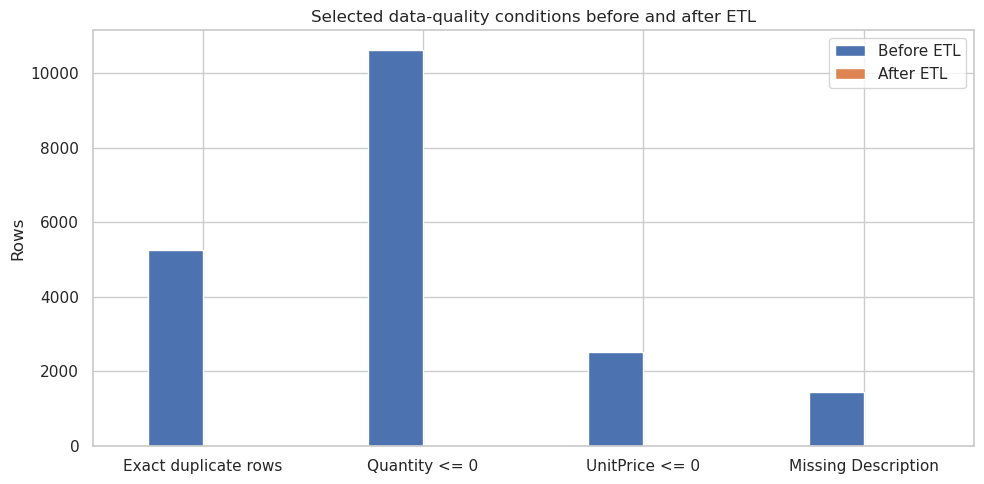

In [38]:
# I use one simple Matplotlib chart for the raw-versus-clean comparison.
comparison.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Selected data-quality conditions before and after ETL")
plt.ylabel("Rows")
plt.tight_layout()
# I save the figure for reuse in the project README before displaying it.
plt.savefig("../Images/Online_Retail_Analysis/online_retail_simple_etl_quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Consequence — the ETL effect is visible

I cannot express how happy I am to see no orange on this visualisation. The before-and-after chart makes the documented quality boundary visible without replacing the underlying counts. With the transformation checked, I now save the validated table for Part 2.

### Cell 11D — save the validated hand-off for Part 2

In [39]:
# I save the validated clean table as the hand-off for the analysis section.
df_clean.to_csv("../outputs/cleaned_online_retail.csv", index=False)
print("Saved cleaned table to ../outputs/cleaned_online_retail.csv")

Saved cleaned table to ../outputs/cleaned_online_retail.csv


### Consequence — the Part 2 hand-off is saved

The cleaned paid-product table has been written to the agreed output path and the hand-off is now reproducible. The next Markdown cell closes Part 1 and tells the reader exactly what Part 2 will reload and verify.

I cannot explain quite what a relief it is to see not one pixel of orange on this visualisation. Fantastic.

# Handover to Part 2 — investigate and visualise

So it should now be apparent why I have chosen to split this project into two notebooks.  Understanding the shape and nature of my chosen dataset was incredibly hard, and it was not assisted by my early misperception of what the data was, or what it  showed.  This has been a valuable lesson to me.  The data alone will tell its own story, and no amount of wishful thinking should be allowed to edit or rewrite that tale.  My Part 1 has now completed the evaluation, cleaning, standardisation, and validation stage. The raw CSV remains the audit source, while the validated paid-product table has been saved as:

`../outputs/cleaned_online_retail.csv`

The saved table is the only starting point Part 2 needs. Before analysing it, the next notebook will reload the file, parse `InvoiceDate` again, check the expected columns and row count, and then continue with the product, market, and time questions. This explicit checkpoint keeps the two notebooks independent of hidden kernel state while preserving the reasoning and audit trail in Part 1.

___